In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("PatrolIQ_ML_Features.csv")

print(df.shape)
df.head()

(497983, 10)


,latitude,longitude,hour,month,is_weekend,crime_severity_score,crime_type_freq,location_freq,district,community_area
0,41.683938,-87.721741,0,8,False,2.0,0.229044,0.194539,22.0,74.0
1,41.891703,-87.612879,0,8,False,2.0,0.068227,0.017234,18.0,8.0
2,41.790291,-87.615871,0,8,False,4.0,0.180677,0.194539,2.0,40.0
3,41.889126,-87.637342,0,8,False,3.0,0.045624,0.017234,18.0,8.0
4,41.746926,-87.606328,0,8,False,3.0,0.045624,0.194539,6.0,44.0


In [3]:
from sklearn.preprocessing import StandardScaler

X = df.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(497983, 10)


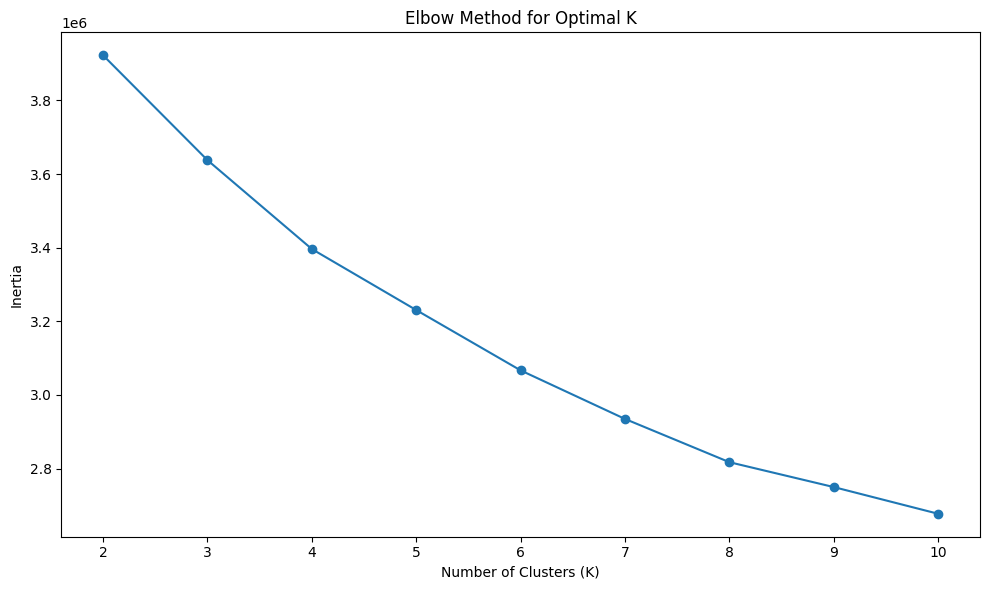

In [4]:
# ==========================================
# K-MEANS - ELBOW METHOD
# ==========================================

from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), inertia, marker="o")

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

In [5]:
print("K  |  Inertia")
for k, value in zip(range(2, 11), inertia):
    print(k, "|", round(value, 2))

K  |  Inertia
2 | 3922495.38
3 | 3637732.38
4 | 3396351.58
5 | 3230605.91
6 | 3066809.65
7 | 2934903.43
8 | 2817487.21
9 | 2749924.99
10 | 2677404.87


In [6]:
# ==========================================
# K-MEANS CLUSTERING
# ==========================================

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

print("K-Means completed!")
print("\nCluster Distribution:")
print(df["cluster"].value_counts().sort_index())

K-Means completed!

Cluster Distribution:
cluster
0    141420
1     64643
2     49417
3    170433
4     72070
Name: count, dtype: int64


In [7]:
# ==========================================
# CLUSTER PROFILE
# ==========================================

cluster_profile = df.groupby("cluster").mean(numeric_only=True)

print(cluster_profile.round(2))

         latitude  longitude   hour  month  is_weekend  crime_severity_score  \
cluster                                                                        
0           41.77     -87.63  12.47   6.66        0.00                  3.23   
1           41.92     -87.69  12.92   6.74        0.28                  2.00   
2           41.79     -87.64  12.72   6.73        0.27                  2.00   
3           41.92     -87.71  12.47   6.67        0.24                  3.20   
4           41.79     -87.65  11.93   6.69        1.00                  3.33   

         crime_type_freq  location_freq  district  community_area  
cluster                                                            
0                   0.09           0.14      6.08           53.02  
1                   0.23           0.10     17.04           18.61  
2                   0.23           0.11      5.60           49.83  
3                   0.09           0.14     16.61           19.87  
4                   0.10       

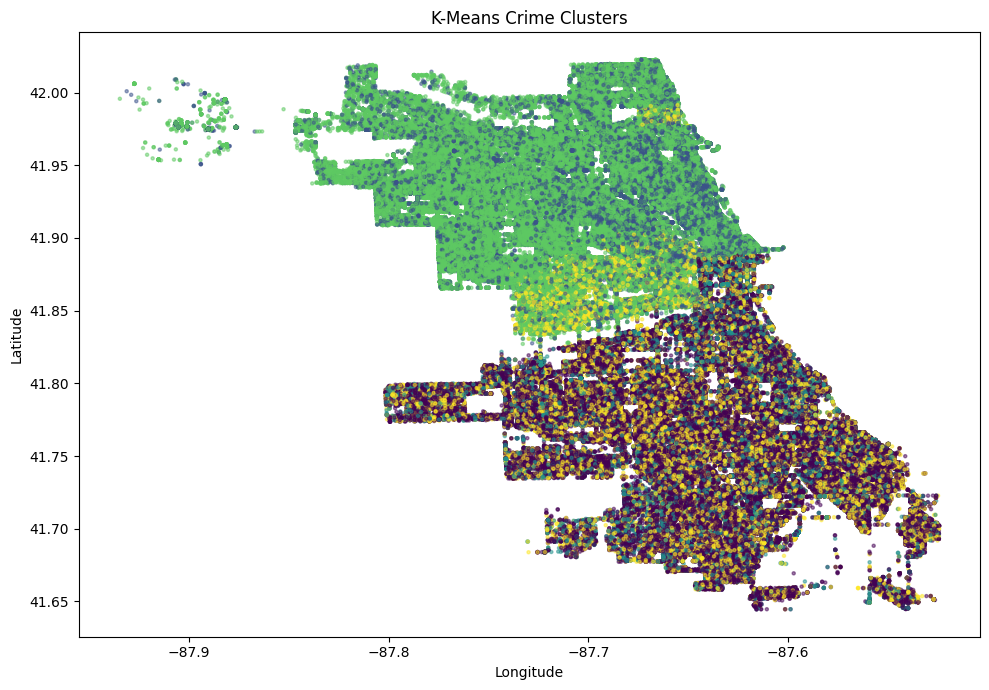

In [8]:
# ==========================================
# K-MEANS CLUSTER VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 7))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["cluster"],
    s=5,
    alpha=0.5
)

plt.title("K-Means Crime Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

In [9]:
# ==========================================
# SILHOUETTE SCORE
# ==========================================

from sklearn.metrics import silhouette_score

sample_size = 10000

sample_indices = np.random.choice(
    len(X_scaled),
    sample_size,
    replace=False
)

sil_score = silhouette_score(
    X_scaled[sample_indices],
    clusters[sample_indices]
)

print("Silhouette Score:", round(sil_score, 3))

Silhouette Score: 0.139


In [10]:
# ==========================================
# SAVE K-MEANS RESULTS
# ==========================================

df.to_csv("PatrolIQ_KMeans_Results.csv", index=False)

print("K-Means results saved!")
print("Shape:", df.shape)

K-Means results saved!
Shape: (497983, 11)


In [11]:
# ==========================================
# DBSCAN CLUSTERING
# ==========================================

from sklearn.cluster import DBSCAN

sample_indices = np.random.choice(
    len(X_scaled),
    10000,
    replace=False
)

X_sample = X_scaled[sample_indices]

dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)

db_labels = dbscan.fit_predict(X_sample)

print("DBSCAN completed!")

print("\nCluster Distribution:")
print(pd.Series(db_labels).value_counts().sort_index())

DBSCAN completed!

Cluster Distribution:
-1     8388
 0       34
 1      398
 2       51
 3       70
 4       62
 5       33
 6      175
 7       23
 8       83
 9      103
 10      13
 11      38
 12      32
 13      10
 14      10
 15      22
 16      10
 17      14
 18      10
 19      21
 20      28
 21      17
 22      20
 23      10
 24      25
 25      15
 26      14
 27      19
 28      17
 29      21
 30      11
 31      14
 32       7
 33      10
 34      18
 35      10
 36      10
 37      17
 38      12
 39      20
 40      10
 41      22
 42      11
 43      10
 44      10
 45      10
 46      12
Name: count, dtype: int64


In [12]:
# ==========================================
# DBSCAN PARAMETER TEST
# ==========================================

for eps in [1.0, 1.2, 1.5, 2.0]:
    
    dbscan = DBSCAN(
        eps=eps,
        min_samples=10
    )
    
    labels = dbscan.fit_predict(X_sample)
    
    clusters_count = len(set(labels)) - (1 if -1 in labels else 0)
    noise_percent = (labels == -1).mean() * 100
    
    print(
        f"eps={eps} | "
        f"Clusters={clusters_count} | "
        f"Noise={noise_percent:.2f}%"
    )

eps=1.0 | Clusters=67 | Noise=51.92%
eps=1.2 | Clusters=41 | Noise=24.44%
eps=1.5 | Clusters=10 | Noise=5.01%
eps=2.0 | Clusters=9 | Noise=0.76%


In [13]:
# ==========================================
# FINAL DBSCAN
# ==========================================

dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

db_labels = dbscan.fit_predict(X_sample)

print("Final DBSCAN completed!")

print("\nCluster Distribution:")
print(pd.Series(db_labels).value_counts().sort_index())

Final DBSCAN completed!

Cluster Distribution:
-1     501
 0    5105
 1    1550
 2    2046
 3     563
 4      36
 5     137
 6      33
 7      10
 8       8
 9      11
Name: count, dtype: int64


In [14]:
# ==========================================
# DBSCAN CLUSTER PROFILE
# ==========================================

dbscan_df = pd.DataFrame(
    X_sample,
    columns=X.columns
)

dbscan_df["cluster"] = db_labels

profile = dbscan_df.groupby("cluster").mean()

print(profile.round(2))

         latitude  longitude  hour  month  is_weekend  crime_severity_score  \
cluster                                                                       
-1           0.34      -0.89 -0.24  -0.03        0.75                  0.18   
 0          -0.06       0.02  0.03  -0.01       -0.64                  0.27   
 1           0.19       0.10  0.08   0.00       -0.64                 -1.11   
 2          -0.10       0.07 -0.06  -0.02        1.56                  0.45   
 3           0.27       0.14  0.05   0.05        1.56                 -1.11   
 4          -1.60       0.16  0.19  -0.05       -0.64                 -1.11   
 5          -1.57       0.14  0.17  -0.07       -0.64                  0.26   
 6           1.59       0.12  0.30  -0.17       -0.64                 -1.11   
 7          -1.66       0.06  0.21   0.22        1.56                 -1.11   
 8           0.29       0.61 -1.68  -0.17        1.56                  0.20   
 9           1.66       0.11 -0.14  -0.76       -0.6

In [15]:
# ==========================================
# DBSCAN SILHOUETTE SCORE
# ==========================================

mask = db_labels != -1

db_silhouette = silhouette_score(
    X_sample[mask],
    db_labels[mask]
)

print("DBSCAN Silhouette Score:", round(db_silhouette, 3))

DBSCAN Silhouette Score: 0.026


In [16]:
# ==========================================
# FINAL UNSUPERVISED LEARNING DATASET
# ==========================================

final_df = df.copy()

final_df.to_csv(
    "PatrolIQ_Final_Clustering_Dataset.csv",
    index=False
)

print("Final dataset saved successfully!")
print("Shape:", final_df.shape)
print("\nColumns:")
print(final_df.columns.tolist())

Final dataset saved successfully!
Shape: (497983, 11)

Columns:
['latitude', 'longitude', 'hour', 'month', 'is_weekend', 'crime_severity_score', 'crime_type_freq', 'location_freq', 'district', 'community_area', 'cluster']


In [17]:
#clustering comparison

In [18]:
# ==========================================
# PHASE 7 - CLUSTERING MODEL COMPARISON
# ==========================================

comparison = pd.DataFrame({
    "Model": ["K-Means", "DBSCAN"],
    "Clusters": [5, 10],
    "Silhouette Score": [0.139, 0.026]
})

print("=" * 60)
print("PHASE 7 - CLUSTERING MODEL COMPARISON")
print("=" * 60)

print(comparison)

PHASE 7 - CLUSTERING MODEL COMPARISON
     Model  Clusters  Silhouette Score
0  K-Means         5             0.139
1   DBSCAN        10             0.026


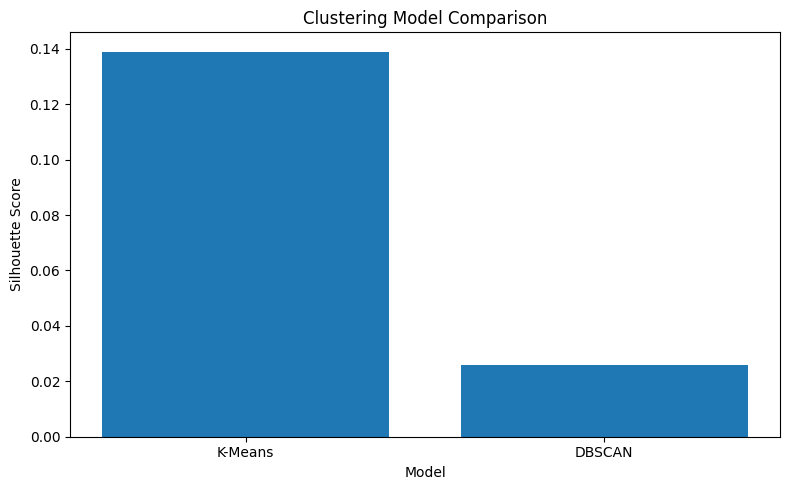

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Silhouette Score"]
)

plt.title("Clustering Model Comparison")
plt.xlabel("Model")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [20]:
best_model = comparison.loc[
    comparison["Silhouette Score"].idxmax(),
    "Model"
]

print("\nBest Clustering Model:", best_model)


Best Clustering Model: K-Means


In [21]:
# ==========================================
# CLUSTER SIZE COMPARISON
# ==========================================

kmeans_sizes = df["cluster"].value_counts().sort_index()

print("=" * 60)
print("K-MEANS CLUSTER SIZES")
print("=" * 60)

print(kmeans_sizes)

print("\nCluster Percentages:")
print((kmeans_sizes / len(df) * 100).round(2))

K-MEANS CLUSTER SIZES
cluster
0    141420
1     64643
2     49417
3    170433
4     72070
Name: count, dtype: int64

Cluster Percentages:
cluster
0    28.40
1    12.98
2     9.92
3    34.22
4    14.47
Name: count, dtype: float64


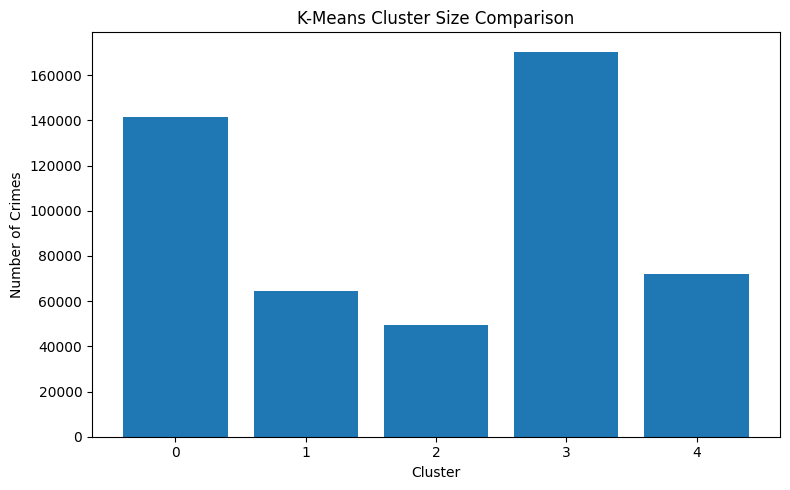

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    kmeans_sizes.index.astype(str),
    kmeans_sizes.values
)

plt.title("K-Means Cluster Size Comparison")
plt.xlabel("Cluster")
plt.ylabel("Number of Crimes")

plt.tight_layout()
plt.show()

In [23]:
# ==========================================
# PHASE 8 - TEMPORAL CLUSTERING
# ==========================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

temporal_features = df[
    ["hour", "month", "is_weekend"]
].copy()

# Convert boolean to integer
temporal_features["is_weekend"] = (
    temporal_features["is_weekend"].astype(int)
)

# Scale
scaler = StandardScaler()

temporal_scaled = scaler.fit_transform(
    temporal_features
)

print("Temporal features ready!")
print(temporal_scaled.shape)

Temporal features ready!
(497983, 3)


In [24]:
# ==========================================
# ELBOW METHOD - TEMPORAL CLUSTERING
# ==========================================

inertia = []

for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(temporal_scaled)
    inertia.append(kmeans.inertia_)

for k, value in zip(range(2, 8), inertia):
    print(f"K={k} | Inertia={value:.2f}")

K=2 | Inertia=995154.85
K=3 | Inertia=735195.93
K=4 | Inertia=567261.67
K=5 | Inertia=446083.10
K=6 | Inertia=374549.12
K=7 | Inertia=305321.74


In [25]:
# ==========================================
# CREATE TEMPORAL CLUSTERS
# ==========================================

temporal_kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

temporal_clusters = temporal_kmeans.fit_predict(
    temporal_scaled
)

df["temporal_cluster"] = temporal_clusters

print("Temporal clustering completed!")

print("\nCluster Distribution:")
print(
    df["temporal_cluster"]
    .value_counts()
    .sort_index()
)

Temporal clustering completed!

Cluster Distribution:
temporal_cluster
0    122069
1    134653
2     87973
3     96605
4     56683
Name: count, dtype: int64


In [26]:
# ==========================================
# TEMPORAL CLUSTER PROFILE
# ==========================================

temporal_profile = (
    df.groupby("temporal_cluster")
    [["hour", "month", "is_weekend"]]
    .mean()
    .round(2)
)

print("=" * 60)
print("TEMPORAL CLUSTER PROFILE")
print("=" * 60)

print(temporal_profile)

TEMPORAL CLUSTER PROFILE
                   hour  month  is_weekend
temporal_cluster                          
0                 15.56   3.44         0.0
1                 16.23   9.43         0.0
2                 17.07   6.67         1.0
3                  3.99   6.94         0.0
4                  4.25   6.72         1.0


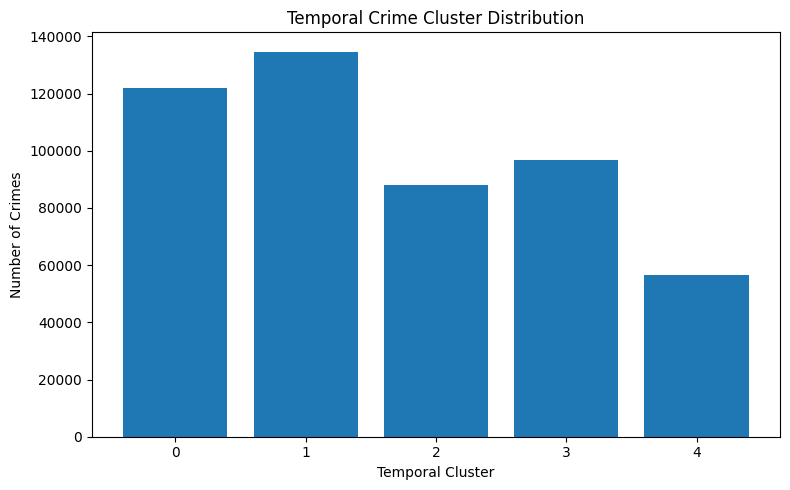

In [27]:
# ==========================================
# TEMPORAL CLUSTER DISTRIBUTION
# ==========================================

cluster_counts = df["temporal_cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title("Temporal Crime Cluster Distribution")
plt.xlabel("Temporal Cluster")
plt.ylabel("Number of Crimes")

plt.tight_layout()
plt.show()

In [28]:
# Save temporal clustering results

df.to_csv(
    "PatrolIQ_Temporal_Clustering.csv",
    index=False
)

print("Temporal clustering dataset saved!")
print("Shape:", df.shape)

Temporal clustering dataset saved!
Shape: (497983, 12)


In [29]:
# ==========================================
# PHASE 9 - DIMENSIONALITY REDUCTION
# ==========================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA completed!")
print("PCA Shape:", X_pca.shape)

print("\nExplained Variance:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:",
      round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

PCA completed!
PCA Shape: (497983, 2)

Explained Variance:
[0.26242267 0.12599216]

Total Variance Explained: 38.84 %


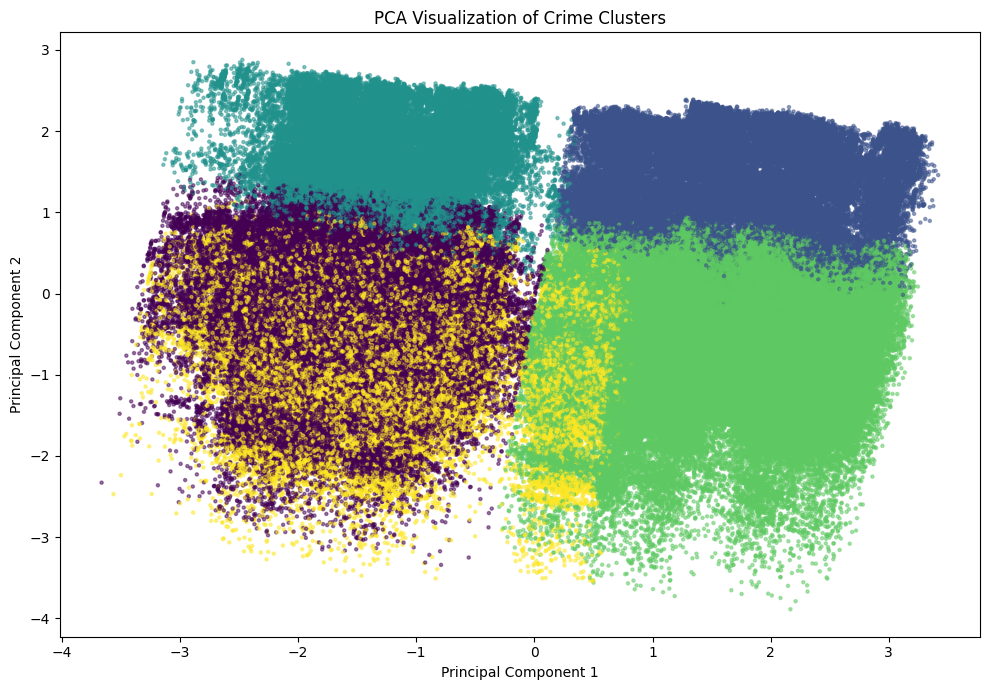

In [30]:
# ==========================================
# PCA CLUSTER VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["cluster"],
    s=5,
    alpha=0.5
)

plt.title("PCA Visualization of Crime Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

In [31]:
# ==========================================
# SAVE PCA COMPONENTS
# ==========================================

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

df.to_csv(
    "PatrolIQ_PCA_Results.csv",
    index=False
)

print("PCA results saved!")
print("Shape:", df.shape)

PCA results saved!
Shape: (497983, 14)


In [32]:
# ==========================================
# PHASE 10 - t-SNE
# ==========================================

from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Sample 10,000 records
sample_indices = np.random.choice(
    len(X_scaled),
    10000,
    replace=False
)

X_sample = X_scaled[sample_indices]
cluster_sample = df["cluster"].iloc[sample_indices]

# t-SNE
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=500
)

X_tsne = tsne.fit_transform(X_sample)

print("t-SNE completed!")
print("t-SNE Shape:", X_tsne.shape)

t-SNE completed!
t-SNE Shape: (10000, 2)


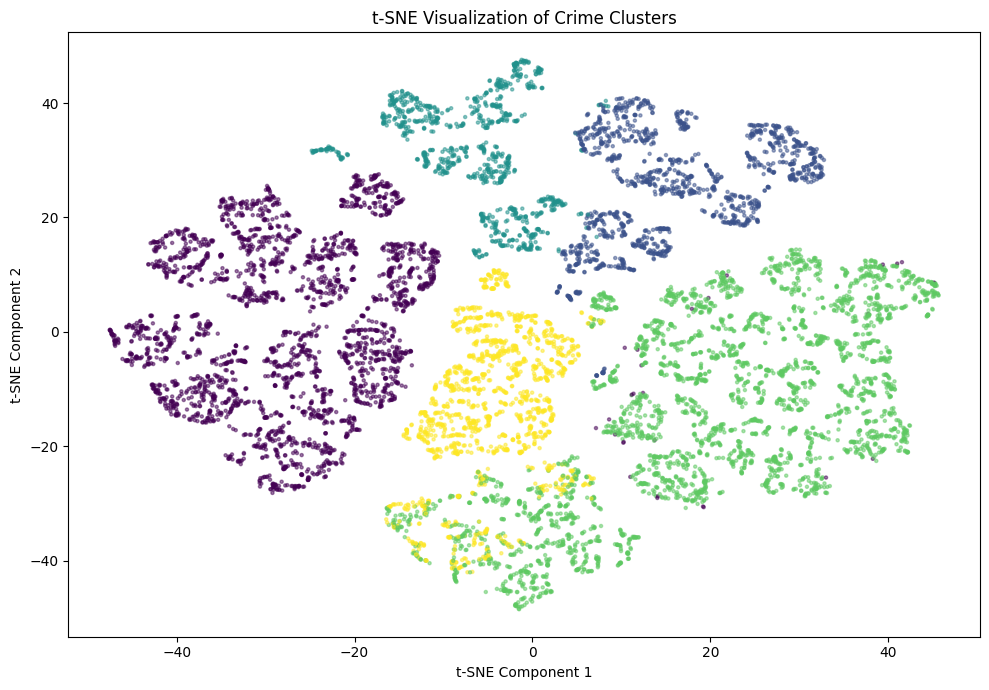

In [33]:
# ==========================================
# t-SNE CLUSTER VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 7))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=cluster_sample,
    s=5,
    alpha=0.5
)

plt.title("t-SNE Visualization of Crime Clusters")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.tight_layout()
plt.show()

In [34]:
# ==========================================
# SAVE t-SNE RESULTS
# ==========================================

tsne_df = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "cluster": cluster_sample.values
})

tsne_df.to_csv(
    "PatrolIQ_tSNE_Results.csv",
    index=False
)

print("t-SNE results saved!")
print("Shape:", tsne_df.shape)

t-SNE results saved!
Shape: (10000, 3)


In [35]:
# ============================================================
# HIERARCHICAL CLUSTERING
# ============================================================

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import pandas as pd

# Use the same sample used for clustering
X_hier = X_sample

# Create Hierarchical Clustering model
hierarchical = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

# Fit model
hier_labels = hierarchical.fit_predict(X_hier)

# Cluster distribution
hierarchical_distribution = pd.Series(hier_labels).value_counts().sort_index()

print("Hierarchical Cluster Distribution:")
print(hierarchical_distribution)

# Save results
hierarchical_results = pd.DataFrame({
    "cluster": hier_labels
})

hierarchical_results.to_csv(
    "PatrolIQ_Hierarchical_Results.csv",
    index=False
)

print("\nHierarchical results saved successfully!")

Hierarchical Cluster Distribution:
0    3628
1    3068
2    1299
3     928
4    1077
Name: count, dtype: int64

Hierarchical results saved successfully!


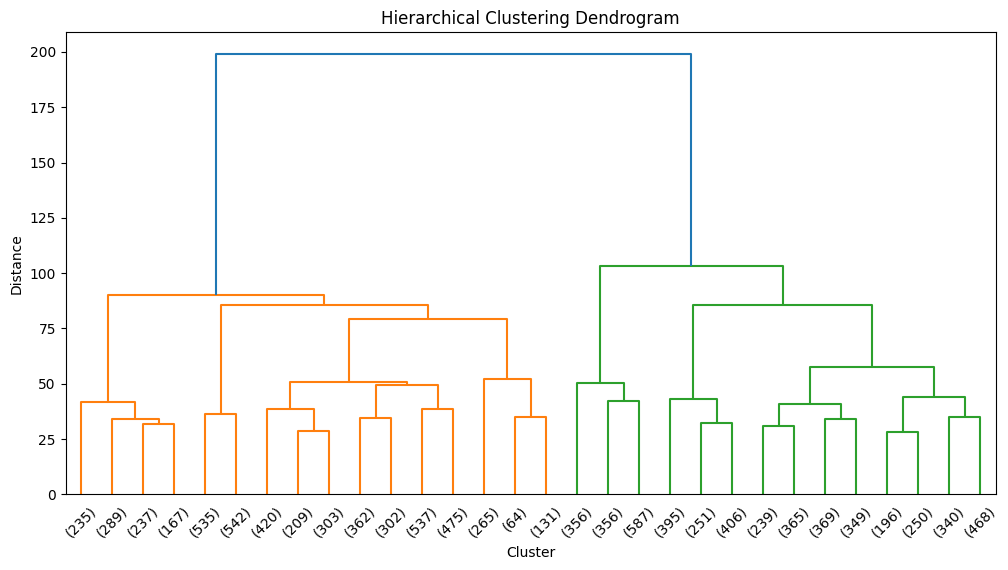

In [38]:
# ============================================================
# HIERARCHICAL CLUSTERING DENDROGRAM
# ============================================================

from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Create linkage matrix
Z = linkage(X_sample, method="ward")

# Plot dendrogram
plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster")
plt.ylabel("Distance")

plt.savefig("PatrolIQ_Hierarchical_Dendrogram.png", bbox_inches="tight")
plt.show()